
# Extending MNIST: Baseline vs Improved Model (PyTorch)

This notebook provides two complete training pipelines for MNIST:
1. **Baseline CNN** — minimal architecture similar to your current code.
2. **Improved CNN** — deeper model with BatchNorm, Dropout, data augmentation, and OneCycleLR.

### How to use
- Ensure you have Python 3.9+ and the following packages: `torch`, `torchvision`, `matplotlib`, `tqdm`, `scikit-learn`.
- Open the notebook and run all cells. If MNIST is not present, it will download automatically.
- GPU is used if available; otherwise CPU is fine (just slower).

> Tip: If you're on CPU, you can reduce `num_epochs` to speed things up.


In [1]:

import os
import math
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import itertools

# Reproducibility
device = torch.device('cpu')


In [2]:

# Common hyperparameters
batch_size = 64
num_epochs_baseline = 10
num_epochs_improved = 15
learning_rate = 1e-3
validation_split = 0.1
data_root = './data'

print(f"Device: {device}")
print(f"Batch size: {batch_size}, Baseline epochs: {num_epochs_baseline}, Improved epochs: {num_epochs_improved}")


Device: cpu
Batch size: 64, Baseline epochs: 10, Improved epochs: 15


## Data & Dataloaders

In [3]:

# Baseline transform (no augmentation)
transform_baseline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# Improved transform (with light augmentation only for training)
transform_train_aug = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# Dataset objects (we'll reuse these for each experiment)
full_train = datasets.MNIST(root=data_root, train=True, download=True, transform=transform_baseline)
test_dataset = datasets.MNIST(root=data_root, train=False, download=True, transform=transform_eval)

# Train/val split indices (fixed split for comparability)
val_size = int(len(full_train) * validation_split)
train_size = len(full_train) - val_size
train_dataset_base, val_dataset = random_split(full_train, [train_size, val_size])

# DataLoaders for baseline
train_loader_base = DataLoader(train_dataset_base, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

len(full_train), len(train_dataset_base), len(val_dataset), len(test_dataset)


(60000, 54000, 6000, 10000)

## Baseline CNN

In [4]:

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # (B,32,14,14)
        x = self.pool(F.relu(self.conv2(x)))  # (B,64,7,7)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


### Training Utilities

In [5]:

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(loader, desc="Train", leave=False, ascii=True)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
        pbar.set_postfix(loss=loss.item())
    return running_loss / len(loader), 100.0 * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, desc="Val"):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(loader, desc=desc, leave=False, ascii=True)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
        pbar.set_postfix(loss=loss.item())
    return running_loss / len(loader), 100.0 * correct / total

def plot_losses(train_losses, val_losses, title="Loss"):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title(title)
    plt.show()


### Train Baseline

Epoch 1/10


Train Loss: 0.1397 | Train Acc: 95.74% | Val Loss: 0.0645 | Val Acc: 97.93%
Epoch 2/10


Train Loss: 0.0332 | Train Acc: 99.01% | Val Loss: 0.0368 | Val Acc: 98.80%
Epoch 3/10


Train Loss: 0.0260 | Train Acc: 99.26% | Val Loss: 0.0349 | Val Acc: 98.87%
Epoch 4/10


Train Loss: 0.0250 | Train Acc: 99.28% | Val Loss: 0.0348 | Val Acc: 98.92%
Epoch 5/10


...

Train Loss: 0.0249 | Train Acc: 99.29% | Val Loss: 0.0347 | Val Acc: 98.92%
Epoch 7/10


Train Loss: 0.0249 | Train Acc: 99.29% | Val Loss: 0.0347 | Val Acc: 98.92%
Epoch 8/10


Train Loss: 0.0249 | Train Acc: 99.29% | Val Loss: 0.0347 | Val Acc: 98.92%
Epoch 9/10


Train Loss: 0.0249 | Train Acc: 99.29% | Val Loss: 0.0347 | Val Acc: 98.92%
Epoch 10/10


Train Loss: 0.0249 | Train Acc: 99.29% | Val Loss: 0.0347 | Val Acc: 98.92%


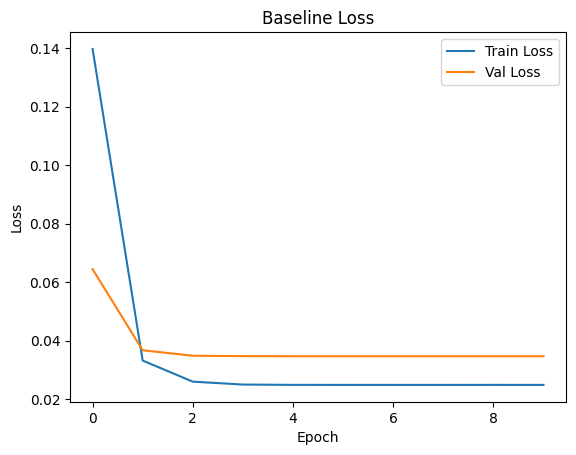

In [6]:

baseline = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)

train_losses_base, val_losses_base = [], []
best_val = float('inf')
best_path_base = "best_mnist_baseline.pth"

for epoch in range(1, num_epochs_baseline + 1):
    print(f"Epoch {epoch}/{num_epochs_baseline}")
    tr_loss, tr_acc = train_one_epoch(baseline, train_loader_base, criterion, optimizer)
    va_loss, va_acc = evaluate(baseline, val_loader, criterion, desc="Val")

    train_losses_base.append(tr_loss)
    val_losses_base.append(va_loss)
    print(f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.2f}% | Val Loss: {va_loss:.4f} | Val Acc: {va_acc:.2f}%")

    if va_loss < best_val:
        best_val = va_loss
        torch.save({'model': baseline.state_dict()}, best_path_base)
    scheduler.step()

plot_losses(train_losses_base, val_losses_base, title="Baseline Loss")


### Test Baseline

In [7]:

# Reload best checkpoint
ckpt = torch.load(best_path_base, map_location=device)
baseline.load_state_dict(ckpt['model'])

test_loss, test_acc = evaluate(baseline, test_loader, criterion, desc="Test")
print(f"Baseline Test Loss: {test_loss:.4f} | Baseline Test Acc: {test_acc:.2f}%")

# Collect predictions for confusion matrix
all_preds, all_labels = [], []
baseline.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = baseline(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_preds)
print("Baseline Classification Report:\n", classification_report(all_labels, all_preds))


Baseline Test Loss: 0.0301 | Baseline Test Acc: 98.97%


Baseline Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.98       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## Improved CNN (BatchNorm + Dropout + Augmentation + OneCycleLR)

In [8]:

# Recreate a training dataset with augmentation applied only to training portion
train_dataset_aug = datasets.MNIST(root=data_root, train=True, download=True, transform=transform_train_aug)
train_dataset_improved, _ = random_split(train_dataset_aug, [len(train_dataset_base), len(train_dataset_aug)-len(train_dataset_base)])

# Use the same val_loader and test_loader for fair comparison
train_loader_improved = DataLoader(train_dataset_improved, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [9]:

class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: 1 -> 32
        self.b1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),      # 14x14
            nn.Dropout(0.10),
        )
        # Block 2: 32 -> 64
        self.b2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),      # 7x7
            nn.Dropout(0.15),
        )
        # Head
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # (B,64,1,1)
        )
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        x = self.b1(x)
        x = self.b2(x)
        x = self.head(x)
        x = torch.flatten(x, 1)  # (B,64)
        x = self.fc(x)
        return x


Epoch 1/15


Train Loss: 0.8785 | Train Acc: 86.04% | Val Loss: 0.4397 | Val Acc: 97.22%
Epoch 2/15


Train Loss: 0.4247 | Train Acc: 97.14% | Val Loss: 0.3959 | Val Acc: 98.00%
Epoch 3/15


Train Loss: 0.3985 | Train Acc: 97.77% | Val Loss: 0.3867 | Val Acc: 98.47%
Epoch 4/15


Train Loss: 0.3839 | Train Acc: 98.14% | Val Loss: 0.3788 | Val Acc: 97.88%
Epoch 5/15


...

Train Loss: 0.3379 | Train Acc: 99.15% | Val Loss: 0.3213 | Val Acc: 99.58%
Epoch 12/15


Train Loss: 0.3336 | Train Acc: 99.25% | Val Loss: 0.3194 | Val Acc: 99.62%
Epoch 13/15


Train Loss: 0.3299 | Train Acc: 99.37% | Val Loss: 0.3147 | Val Acc: 99.67%
Epoch 14/15


Train Loss: 0.3281 | Train Acc: 99.39% | Val Loss: 0.3139 | Val Acc: 99.67%
Epoch 15/15


Train Loss: 0.3272 | Train Acc: 99.44% | Val Loss: 0.3130 | Val Acc: 99.72%


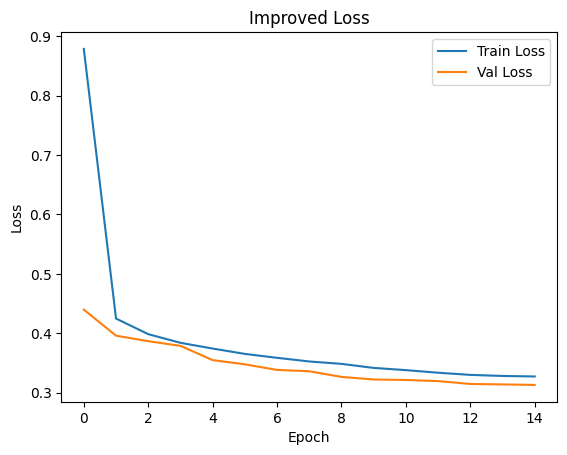

In [10]:

improved = ImprovedCNN().to(device)
criterion_improved = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer_improved = optim.AdamW(improved.parameters(), lr=learning_rate, weight_decay=1e-4)

# OneCycleLR needs steps_per_epoch
steps_per_epoch = math.ceil(len(train_loader_improved))
scheduler_improved = optim.lr_scheduler.OneCycleLR(
    optimizer_improved,
    max_lr=5e-3,
    epochs=num_epochs_improved,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.3,
    div_factor=10.0,
    final_div_factor=1e2
)

train_losses_imp, val_losses_imp = [], []
best_val_imp = float('inf')
best_path_imp = "best_mnist_improved.pth"

for epoch in range(1, num_epochs_improved + 1):
    print(f"Epoch {epoch}/{num_epochs_improved}")
    # Custom train loop to step OneCycleLR each batch
    improved.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(train_loader_improved, desc="Train*", leave=False, ascii=True)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer_improved.zero_grad()
        outputs = improved(images)
        loss = criterion_improved(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(improved.parameters(), max_norm=5.0)
        optimizer_improved.step()
        scheduler_improved.step()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
        pbar.set_postfix(loss=loss.item())
    tr_loss = running_loss / len(train_loader_improved)
    tr_acc  = 100.0 * correct / total

    va_loss, va_acc = evaluate(improved, val_loader, criterion_improved, desc="Val*")
    train_losses_imp.append(tr_loss)
    val_losses_imp.append(va_loss)
    print(f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.2f}% | Val Loss: {va_loss:.4f} | Val Acc: {va_acc:.2f}%")

    if va_loss < best_val_imp:
        best_val_imp = va_loss
        torch.save({'model': improved.state_dict()}, best_path_imp)

plot_losses(train_losses_imp, val_losses_imp, title="Improved Loss")


Improved Test Loss: 0.3164 | Improved Test Acc: 99.53%


Collected 47 misclassified samples.


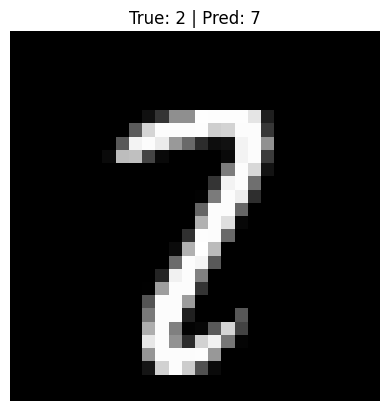

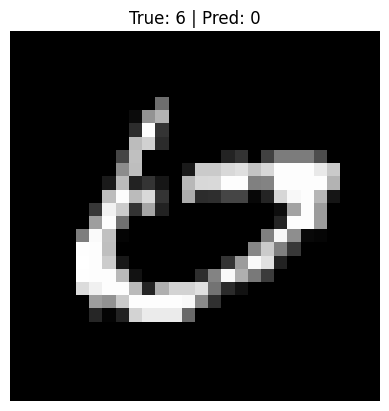

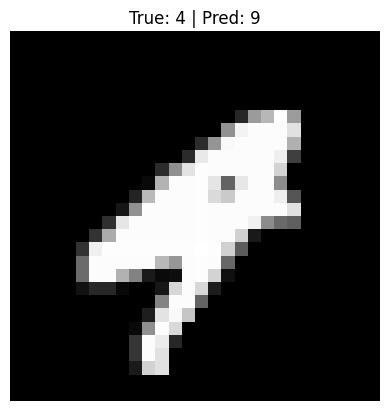

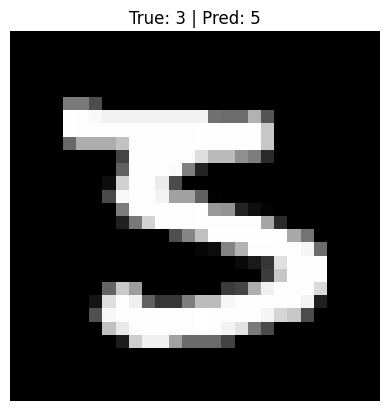

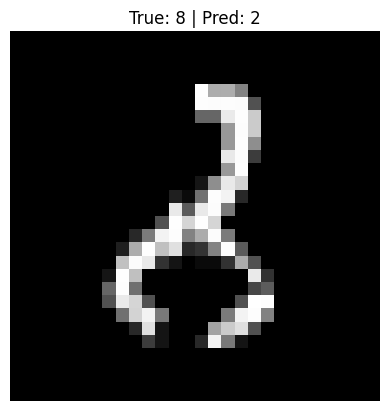

Improved Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      1.00      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       1.00      0.99      1.00       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.99      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



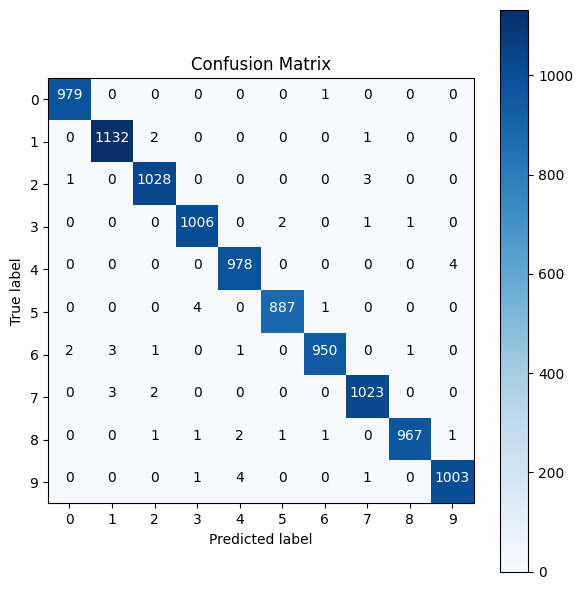

In [11]:

# Reload best improved
ckpt_imp = torch.load(best_path_imp, map_location=device)
improved.load_state_dict(ckpt_imp['model'])

test_loss_imp, test_acc_imp = evaluate(improved, test_loader, criterion_improved, desc="Test*")
print(f"Improved Test Loss: {test_loss_imp:.4f} | Improved Test Acc: {test_acc_imp:.2f}%")

# Misclassifications
mis_images, mis_true, mis_pred = [], [], []
improved.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = improved(images)
        _, preds = outputs.max(1)
        mismask = preds.ne(labels)
        if mismask.any():
            mis_images.extend(images[mismask].cpu())
            mis_true.extend(labels[mismask].cpu())
            mis_pred.extend(preds[mismask].cpu())

print(f"Collected {len(mis_images)} misclassified samples.")

def imshow(img, title=None):
    # img is a tensor with shape (1, 28, 28)
    img = img.cpu().clone()
    npimg = img.squeeze(0).numpy()
    plt.figure()
    plt.imshow(npimg, cmap='gray')
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

# Show a few misclassified images
for i in range(min(5, len(mis_images))):
    imshow(mis_images[i], f"True: {mis_true[i].item()} | Pred: {mis_pred[i].item()}")

# Confusion matrix
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = improved(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_preds)
print("Improved Classification Report:\n", classification_report(all_labels, all_preds))

# Plot confusion matrix
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(6,6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, classes=[str(i) for i in range(10)])



## Notes & Expected Results

- On GPU, the **baseline** typically reaches ~98–99% test accuracy within ~10 epochs.
- The **improved** model often reaches ~99.2–99.5%+ with 15 epochs thanks to augmentation, BatchNorm, Dropout, and OneCycleLR.
- If you're training on CPU, accuracy will be similar but training will take longer. Reduce epochs if needed.
- You can further tune `max_lr`, dropout rates, augmentation ranges, and epoch counts for even better performance.
